In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import joblib

In [4]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [5]:
df.info

<bound method DataFrame.info of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL 

In [6]:
df.head
df.shape
df.describe
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"].fillna(
    df["TotalCharges"].median(),
    inplace=True
)

0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

In [ ]:
df.drop("customerID",axis=1,inplace=True)


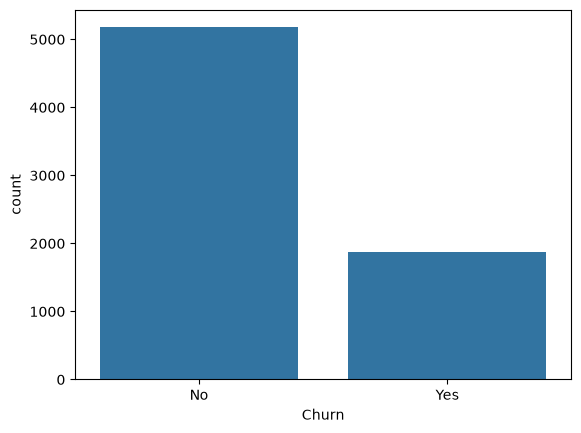

In [10]:
sns.countplot(x="Churn",data=df)
plt.show()

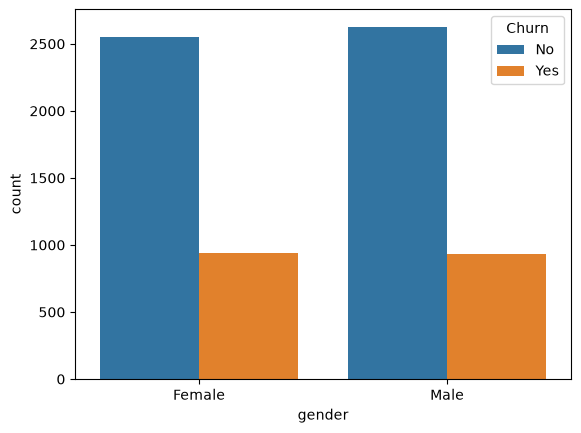

In [11]:
sns.countplot(x="gender",hue="Churn",data=df)
plt.show()

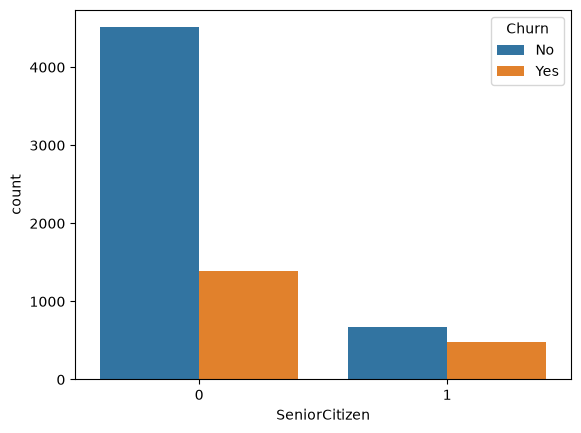

In [12]:
sns.countplot(x="SeniorCitizen",hue="Churn",data=df)
plt.show()

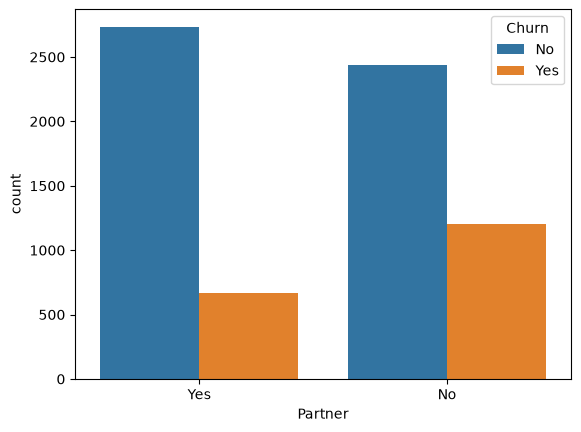

In [13]:
sns.countplot(x="Partner",hue="Churn",data=df)
plt.show()

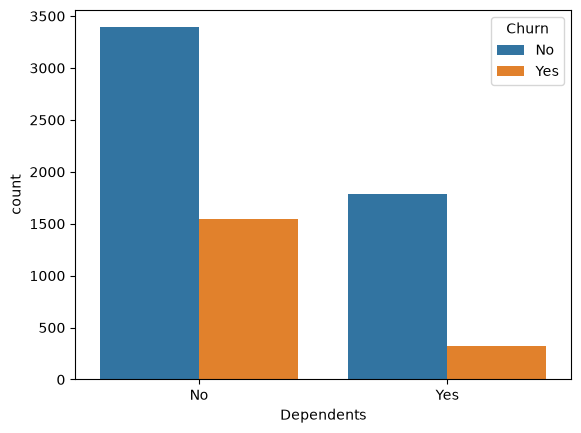

In [14]:
sns.countplot(x="Dependents",hue="Churn",data=df)
plt.show()

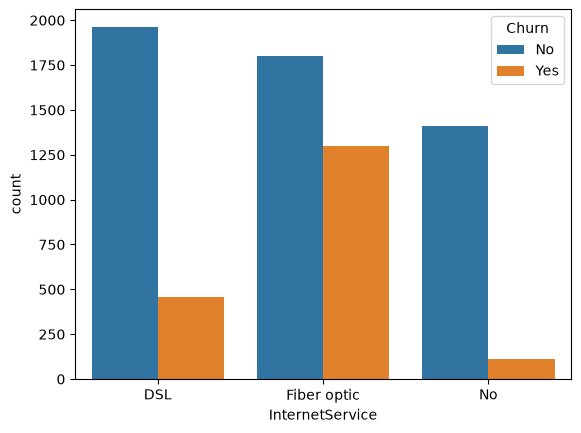

In [15]:
sns.countplot(x="InternetService",hue="Churn",data=df)
plt.show()

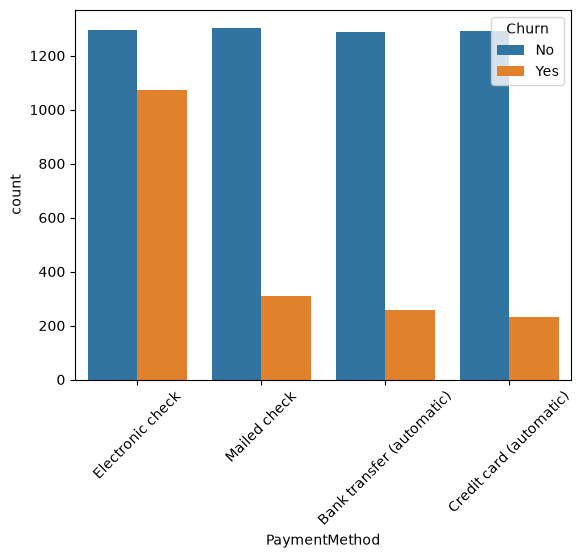

In [16]:
sns.countplot(
    x="PaymentMethod",
    hue="Churn",
    data=df
)

plt.xticks(rotation=45)

plt.show()

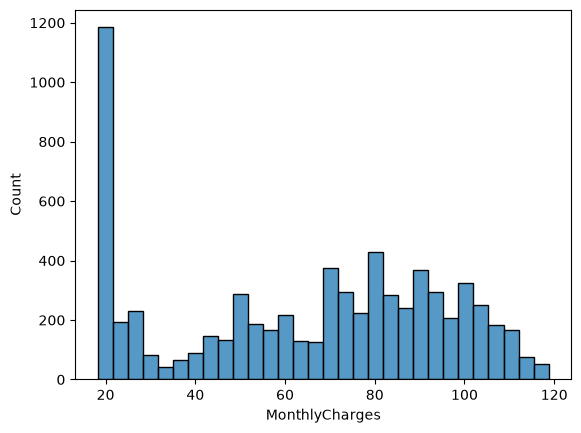

In [17]:
sns.histplot(df["MonthlyCharges"],bins=30)
plt.show()

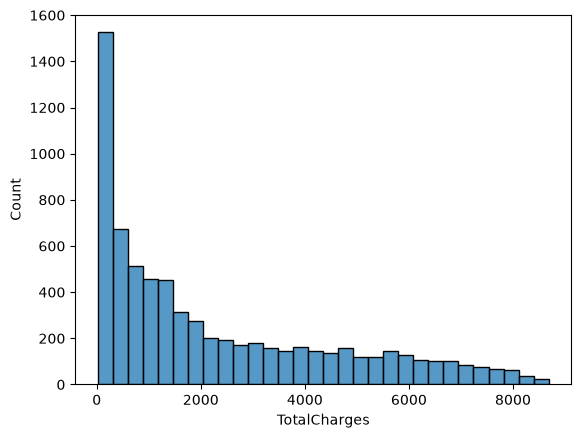

In [18]:
sns.histplot(df["TotalCharges"],bins=30)
plt.show()

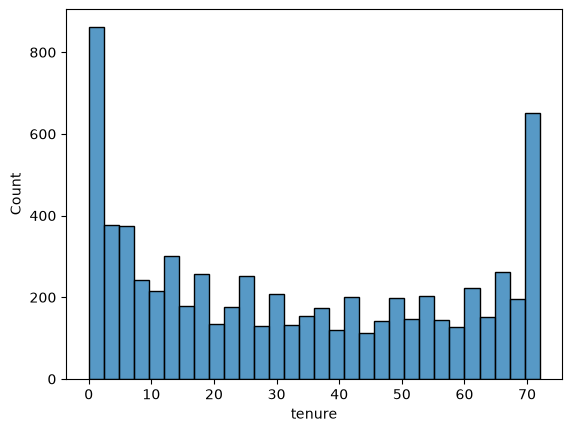

In [19]:
sns.histplot(df["tenure"],bins=30)
plt.show()

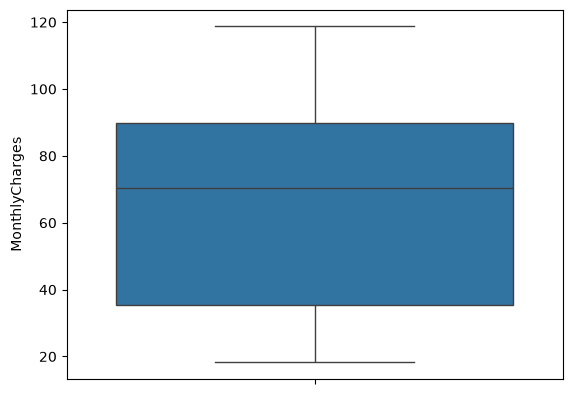

In [20]:
sns.boxplot(y=df["MonthlyCharges"])
plt.show()

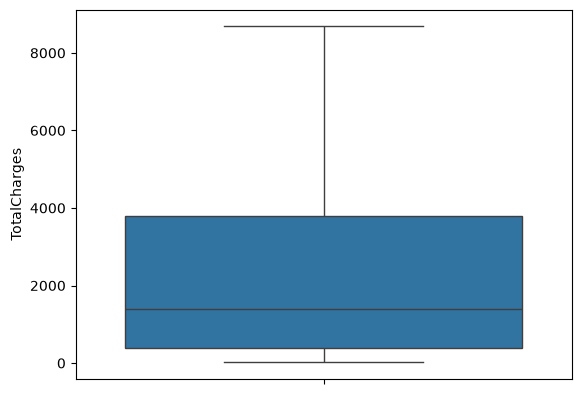

In [21]:
sns.boxplot(y=df["TotalCharges"])
plt.show()

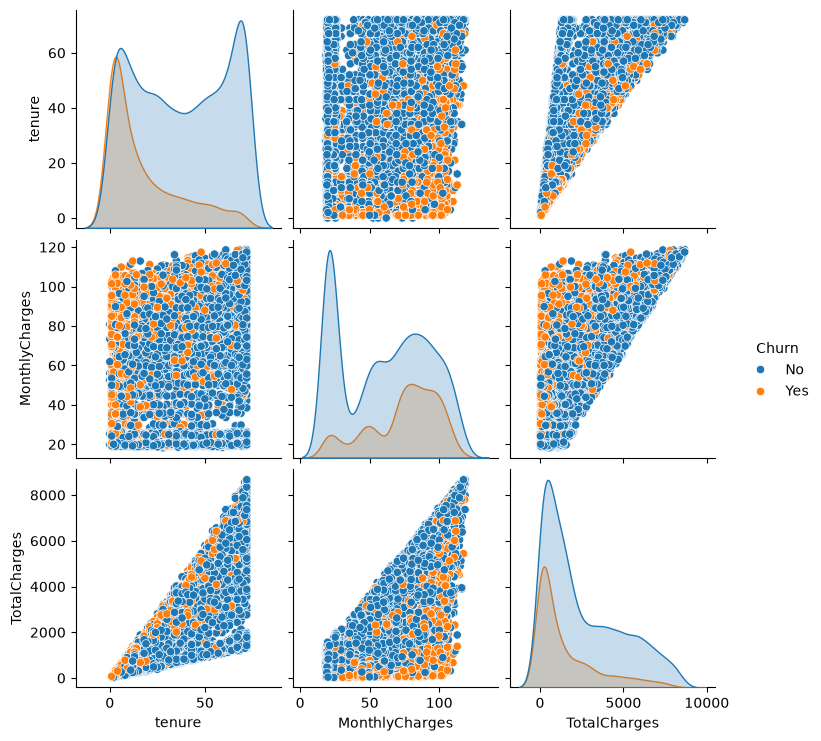

In [22]:
sns.pairplot(
    df[["tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Churn"]],
    hue="Churn"
)

In [23]:
encoder=LabelEncoder()

for col in df.columns:
    if df[col].dtype=="object":
        df[col]=encoder.fit_transform(df[col])

In [25]:
df["CustomerValue"]=df["MonthlyCharges"]*df["tenure"]

df["AverageCharge"]=df["TotalCharges"]/(df["tenure"]+1)

In [26]:
X=df.drop("Churn",axis=1)

y=df["Churn"]

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(
X,
y,
test_size=0.2,
random_state=42,
stratify=y
)

In [32]:
print(X_train.dtypes)

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
CustomerValue       float64
AverageCharge       float64
dtype: object


In [34]:
print(df.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'CustomerValue',
       'AverageCharge'],
      dtype='str')


In [35]:
print(df.dtypes)


gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
CustomerValue       float64
AverageCharge       float64
dtype: object


In [36]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print(df.dtypes)

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
CustomerValue       float64
AverageCharge       float64
dtype: object


In [37]:
print(df.select_dtypes(include=['object']).columns)

Index([], dtype='str')


In [38]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [40]:
print(df.isnull().sum())

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges         0
Churn                0
CustomerValue        0
AverageCharge       11
dtype: int64


In [41]:
# Fill missing values in all numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [42]:
print(df.isnull().sum().sum())

0


In [43]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [45]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, pred_lr))

Accuracy: 0.8055358410220014


In [46]:
dt=DecisionTreeClassifier()

dt.fit(X_train,y_train)

pred_dt=dt.predict(X_test)

print(accuracy_score(y_test,pred_dt))

0.7288857345635202


In [47]:
rf=RandomForestClassifier(
n_estimators=300,
random_state=42
)

rf.fit(X_train,y_train)

pred_rf=rf.predict(X_test)

print(accuracy_score(y_test,pred_rf))

0.7885024840312278


In [49]:
from xgboost import XGBClassifier

xgb=XGBClassifier()

xgb.fit(X_train,y_train)

pred_xgb=xgb.predict(X_test)

print(accuracy_score(y_test,pred_xgb))

0.7799858055358411


In [50]:
models=["LR","DT","RF","XGB"]

accuracy=[
accuracy_score(y_test,pred_lr),
accuracy_score(y_test,pred_dt),
accuracy_score(y_test,pred_rf),
accuracy_score(y_test,pred_xgb)
]

pd.DataFrame({
"Model":models,
"Accuracy":accuracy
})

,Model,Accuracy
0,LR,0.805536
1,DT,0.728886
2,RF,0.788502
3,XGB,0.779986


In [51]:
param_grid={
"n_estimators":[100,200,300],
"max_depth":[5,10,15]
}

grid=GridSearchCV(
RandomForestClassifier(),
param_grid,
cv=5
)

grid.fit(X_train,y_train)

print(grid.best_params_)

{'max_depth': 10, 'n_estimators': 100}


In [52]:
importance=pd.DataFrame({
"Feature":X.columns,
"Importance":rf.feature_importances_
})

importance.sort_values(
by="Importance",
ascending=False
)

,Feature,Importance
17,MonthlyCharges,0.124825
18,TotalCharges,0.122117
20,AverageCharge,0.121152
19,CustomerValue,0.120331
4,tenure,0.111463
14,Contract,0.074898
8,OnlineSecurity,0.042748
16,PaymentMethod,0.040626
11,TechSupport,0.035209
7,InternetService,0.025922


In [56]:
joblib.dump(rf,"customer_churn.pkl")

['customer_churn.pkl']

In [57]:
import joblib

model = joblib.load("customer_churn.pkl")

In [58]:
sample = X.iloc[[0]]

prediction = model.predict(sample)

if prediction[0] == 1:
    print("Customer is likely to churn")
else:
    print("Customer is likely to stay")

Customer is likely to stay


Top Churn Factors:
1. Contract Type
2. Monthly Charges
3. Tenure
4. Tech Support
5. Online Security

Recommendations:
• Encourage long-term contracts.
• Offer discounts to high-risk customers.
• Improve technical support.
• Target customers with high monthly charges using retention campaigns.
• Provide personalized loyalty rewards for new customers.